### Overfitting

In this notebook we demonstrate the effects of overfitting and show some techniques to combat it. We will be using a CNN-based binary classifier on the famous [cat vs dogs](https://www.kaggle.com/c/dogs-vs-cats/data) dataset.

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

#### Dataset

Let's very briefly inspect the dataset.

Cats 12500
Dogs 12500


(<Axes: >, <matplotlib.image.AxesImage at 0x1492b4290>)

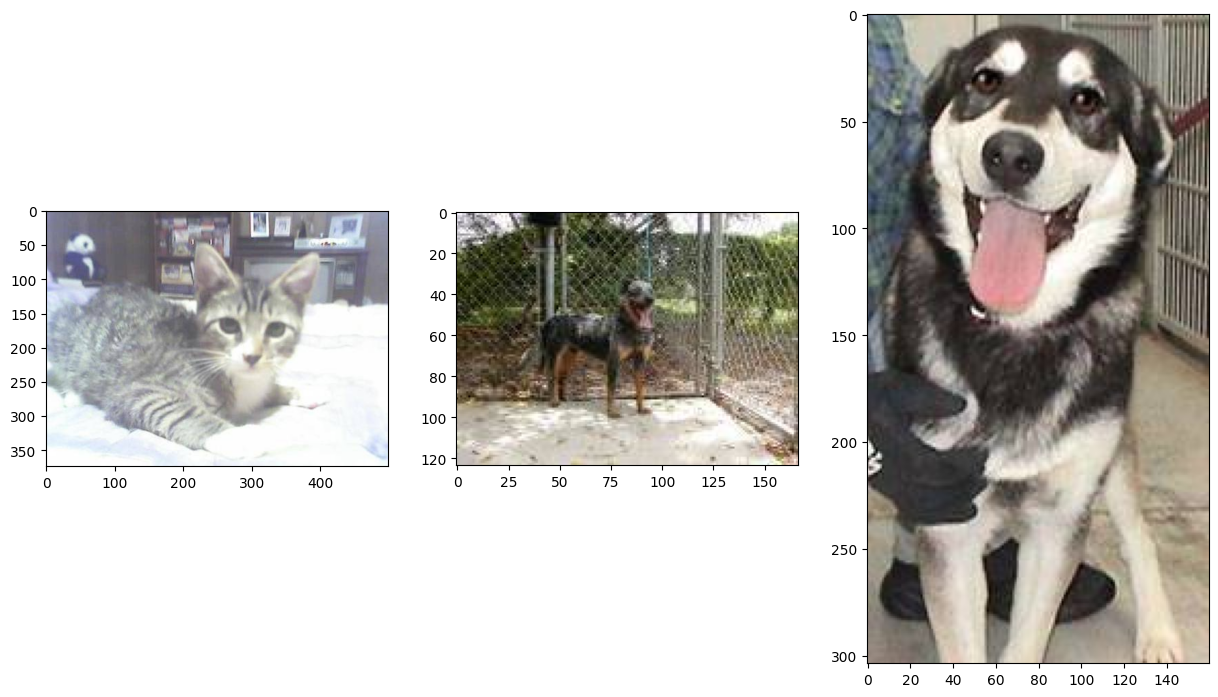

In [5]:
folder = 'data/train'
samples = os.listdir(folder)

print('Cats', len([s for s in samples if 'cat' in s]))
print('Dogs', len([s for s in samples if 'dog' in s]))

img = cv2.cvtColor(cv2.imread(os.path.join(folder, np.random.choice(samples))), cv2.COLOR_BGR2RGB)
plt.subplot(131), plt.imshow(img)
img = cv2.cvtColor(cv2.imread(os.path.join(folder, np.random.choice(samples))), cv2.COLOR_BGR2RGB)
plt.subplot(132), plt.imshow(img)
img = cv2.cvtColor(cv2.imread(os.path.join(folder, np.random.choice(samples))), cv2.COLOR_BGR2RGB)
plt.subplot(133), plt.imshow(img)

Now it is the time to load the data. We will normalize the dimensions to a specific image size.

In [9]:
size = 64
x, y = [], []

for sample in tqdm(samples):
    img = cv2.cvtColor(cv2.imread(os.path.join(folder, sample)), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    x.append(img)
    if 'cat' in sample:
        y.append(0)
    elif 'dog' in sample:
        y.append(1)
    else:
        raise ValueError()

100%|████████████████████████████████████| 25000/25000 [01:17<00:00, 321.60it/s]


Let's split the data into training and validation subsets and normalize the pixel values.

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, shuffle=True)

x_train = np.array(x_train)/255
x_test = np.array(x_test)/255

y_train = np.array(y_train)
y_test = np.array(y_test)

print(x_train.shape, len(y_train))

(20000, 64, 64, 3) 20000


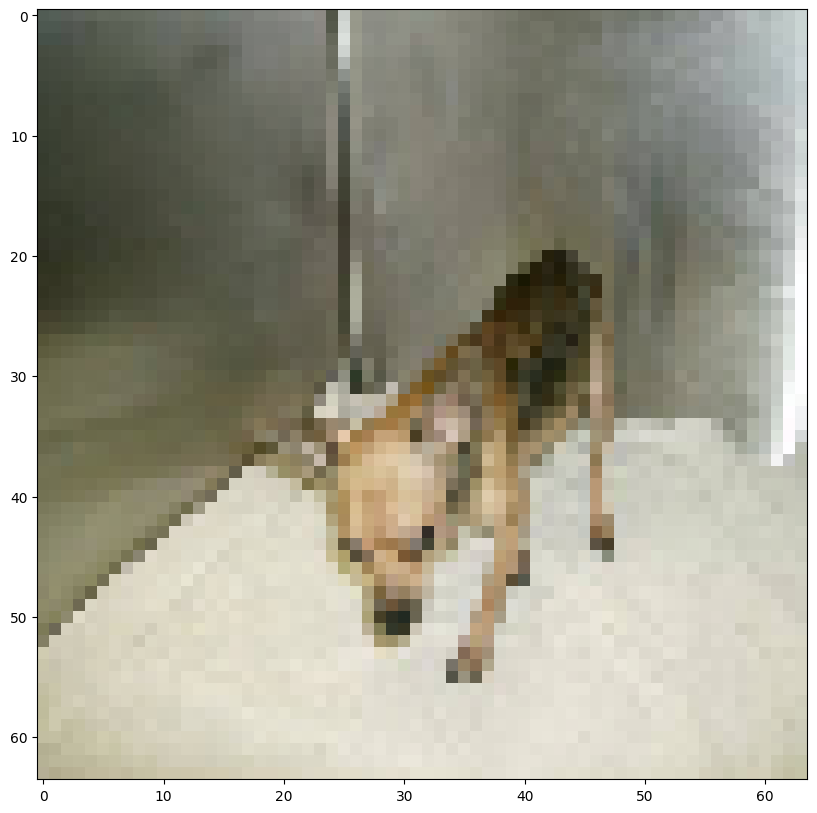

In [13]:
plt.imshow(x_train[1000, ...])

### Dog vs Cat Classification

We will start by building a simple CNN-based binary classifier.

In [16]:
inputs = Input(shape=(size, size, 3))

net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
net = Dense(128, activation="relu")(net)
outputs = Dense(1, activation="sigmoid")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

And let's start training ;-)

In [19]:
epochs = 50
batch_size = 64

print(x_train.shape)

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))
print('Elapsed time', time() - start)

(20000, 64, 64, 3)
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 172ms/step - accuracy: 0.6296 - loss: 0.6258 - val_accuracy: 0.7292 - val_loss: 0.5377
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.7503 - loss: 0.5085 - val_accuracy: 0.7682 - val_loss: 0.4888
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.8011 - loss: 0.4325 - val_accuracy: 0.7920 - val_loss: 0.4525
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.8317 - loss: 0.3751 - val_accuracy: 0.8084 - val_loss: 0.4141
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.8595 - loss: 0.3237 - val_accuracy: 0.7924 - val_loss: 0.4352
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 160ms/step - accuracy: 0.8842 - loss: 0.2761 - val_accuracy: 0.7968 - val_loss: 0.4298
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.9017 - loss: 0.2408 - val_accuracy: 0.7864 - val_loss: 0.4714
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accurac

Train Acc      0.9940500259399414
Validation Acc 0.828000009059906


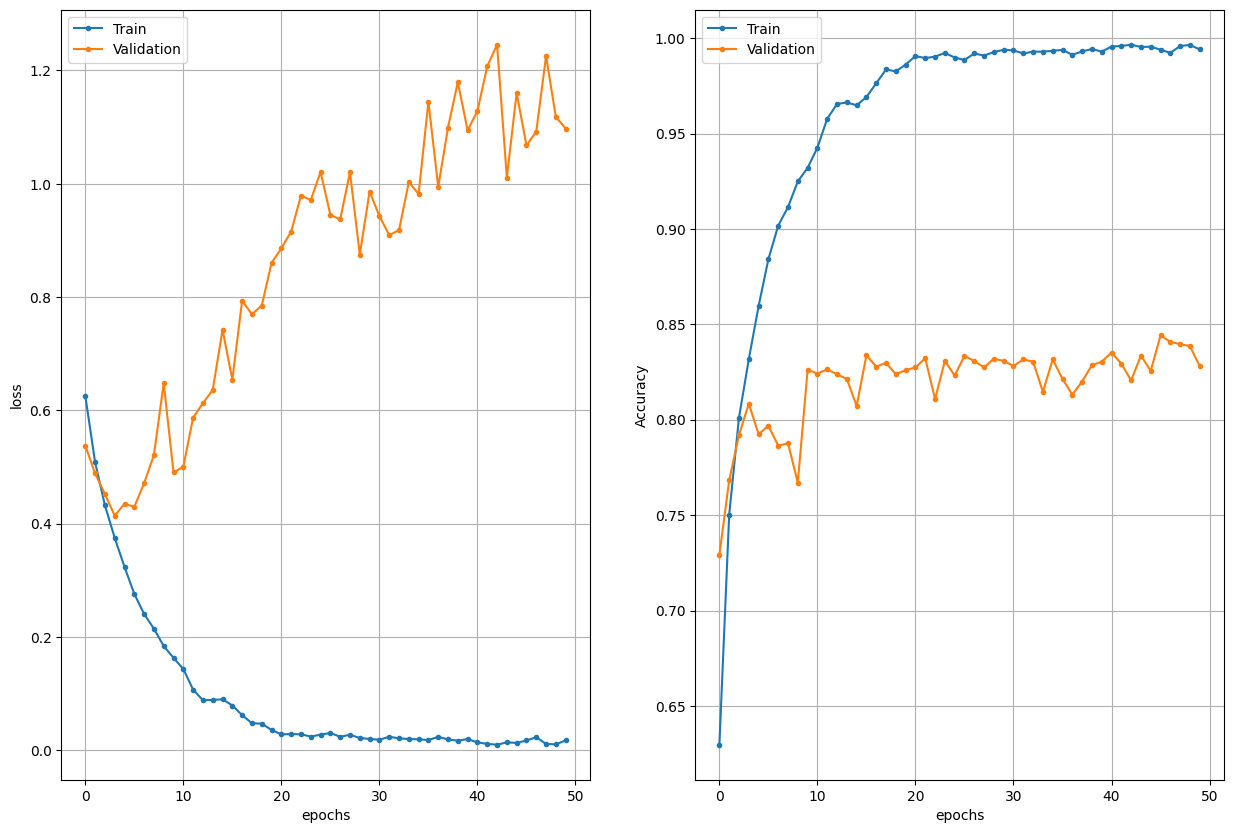

In [21]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

This experiment suffers from a considerable overfitting (the training loss and accuracy are far better than the validation performance). We need to apply some of the techniques seen in the lectures to combat this effect.

### Regularizations

To reduce the negative effect of overfitting, we will insert droput layers after each convolution and before the last fully connected layer. Furthermore, we reduce the size of the dense layer after flatten. Note that reducing the network complexity is also a form of regularization.

In [25]:
inputs2 = Input(shape=(size, size, 3))

net2 = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs2)
net2 = MaxPooling2D(pool_size=(2, 2))(net2)
net2 = Dropout(0.2)(net2)
net2 = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net2)
net2 = MaxPooling2D(pool_size=(2, 2))(net2)
net2 = Dropout(0.2)(net2)
net2 = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same')(net2)
net2 = MaxPooling2D(pool_size=(2, 2))(net2)
net2 = Dropout(0.2)(net2)
net2 = Flatten()(net2)
net2 = Dense(64, activation="relu")(net2)
net2 = Dropout(0.5)(net2)
outputs2 = Dense(1, activation="sigmoid")(net2)

model2 = Model(inputs2, outputs2)
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,665 (2.36 MB)

 Trainable params: 617,665 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
epochs = 50
batch_size = 64

print(x_train.shape)

model2.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time()
history2 = model2.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))
print('Elapsed time', time() - start)

(20000, 64, 64, 3)
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 179ms/step - accuracy: 0.5871 - loss: 0.6646 - val_accuracy: 0.6786 - val_loss: 0.5900
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 174ms/step - accuracy: 0.6981 - loss: 0.5834 - val_accuracy: 0.7448 - val_loss: 0.5290
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.7506 - loss: 0.5163 - val_accuracy: 0.7958 - val_loss: 0.4580
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.7832 - loss: 0.4723 - val_accuracy: 0.8142 - val_loss: 0.4149
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 176ms/step - accuracy: 0.8027 - loss: 0.4417 - val_accuracy: 0.8260 - val_loss: 0.3861
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 177ms/step - accuracy: 0.8137 - loss: 0.4134 - val_accuracy: 0.8248 - val_loss: 0.3944
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 176ms/step - accuracy: 0.8260 - loss: 0.3923 - val_accuracy: 0.8290 - val_loss: 0.3796
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accurac

Train Acc      0.9523000121116638
Validation Acc 0.876800000667572


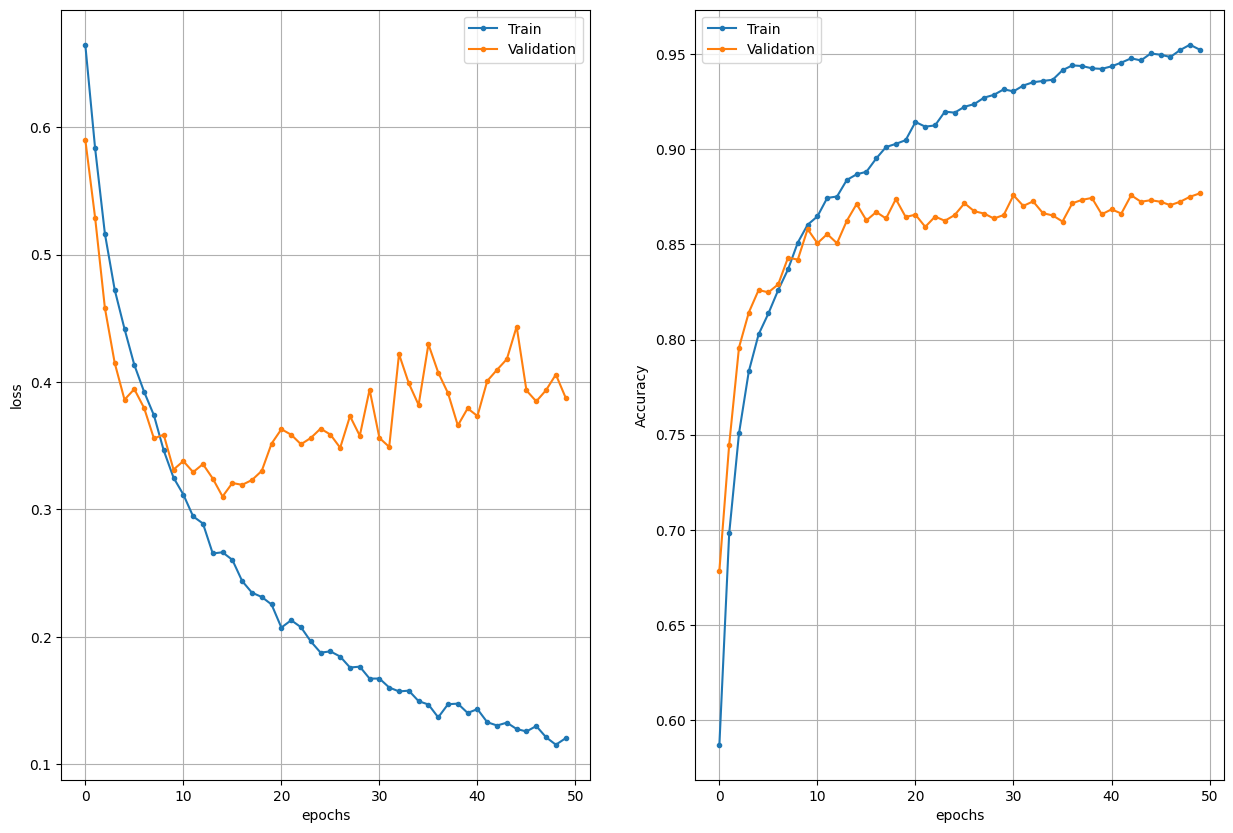

In [29]:
plot_history(history2)

The results look better now but there is still a significat performance gap between training and validation.

### Data Augmentation

As a next step, data augmentation is applied. We build a data generator and, in this simple example, we will add the so called *mirroring* as the only augmentation technique. In general, there is a large variety of augmentation you can experiment with (gamma correction, adding noise, blurring, sharpening, brightness modification, color (un)balancing, etc.).

Note that data augmentation is applied only to training data.

In [33]:
from sklearn.utils import shuffle

def datagen(x, y, batch_size):
    num_samples = len(y)
    while True:
        for idx in range(0, num_samples, batch_size):
            x_ = x[idx:idx + batch_size, ...]
            y_ = y[idx:idx + batch_size]
            
            if len(y_) < batch_size:
                x, y = shuffle(x, y)
                break
            
            # Augmentation
            for idx_aug in range(batch_size):
                if np.random.rand() > 0.5:
                    x_[idx_aug, ...] = np.fliplr(x_[idx_aug, ...])                                
                    
            yield x_, y_

In [35]:
inputs3 = Input(shape=(size, size, 3))

net3 = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs3)
net3 = MaxPooling2D(pool_size=(2, 2))(net3)
net3 = Dropout(0.2)(net3)
net3 = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net3)
net3 = MaxPooling2D(pool_size=(2, 2))(net3)
net3 = Dropout(0.2)(net3)
net3 = Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same')(net3)
net3 = MaxPooling2D(pool_size=(2, 2))(net3)
net3 = Dropout(0.2)(net3)
net3 = Flatten()(net3)
net3 = Dense(64, activation="relu")(net3)
net3 = Dropout(0.5)(net3)
outputs3 = Dense(1, activation="sigmoid")(net3)

model3 = Model(inputs3, outputs3)
model3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,665 (2.36 MB)

 Trainable params: 617,665 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
epochs = 50
batch_size = 64
steps_per_epoch = len(y_train) // batch_size
generator = datagen(x_train, y_train, batch_size)
print(x_train.shape)

model3.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time()
history3 = model3.fit(generator, steps_per_epoch=steps_per_epoch, epochs=epochs, validation_data=(x_test, y_test))
print('Elapsed time', time() - start)

(20000, 64, 64, 3)
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 182ms/step - accuracy: 0.6052 - loss: 0.6566 - val_accuracy: 0.7142 - val_loss: 0.5619
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.7193 - loss: 0.5496 - val_accuracy: 0.7660 - val_loss: 0.4883
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 176ms/step - accuracy: 0.7563 - loss: 0.5005 - val_accuracy: 0.7862 - val_loss: 0.4532
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.7873 - loss: 0.4603 - val_accuracy: 0.8136 - val_loss: 0.4100
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.8060 - loss: 0.4244 - val_accuracy: 0.8324 - val_loss: 0.3798
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 168ms/step - accuracy: 0.8240 - loss: 0.3948 - val_accuracy: 0.8506 - val_loss: 0.3462
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 168ms/step - accuracy: 0.8350 - loss: 0.3703 - val_accuracy: 0.8558 - val_loss: 0.3301
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accurac

Train Acc      0.9392527937889099
Validation Acc 0.8992000222206116


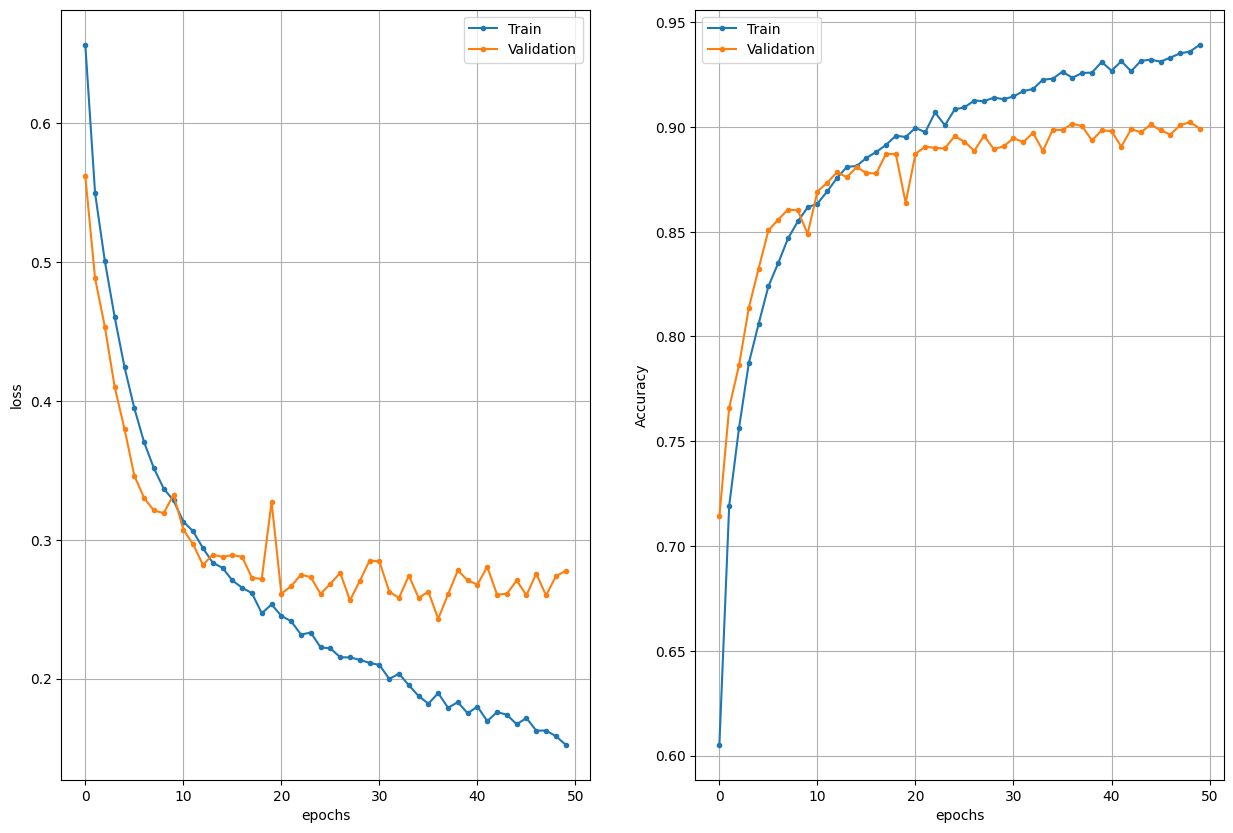

In [39]:
plot_history(history3)

The results look much better now. Even though the training accuracy is lower than before, the important thing is that validation performance has increased and is above 90% of accuracy now. We can further experiment with different (more complex) architectures and more complex data augmentators.